Video presentasi: https://drive.google.com/drive/folders/1QrVhhmqQCJuAX4GiaGiQDSW5Pp9wb_CK?usp=sharing

# Soal 3a
Jelaskan cara kerja dari arsitektur tersebut yang dideskripsikan dalam
gambar di bawah ini: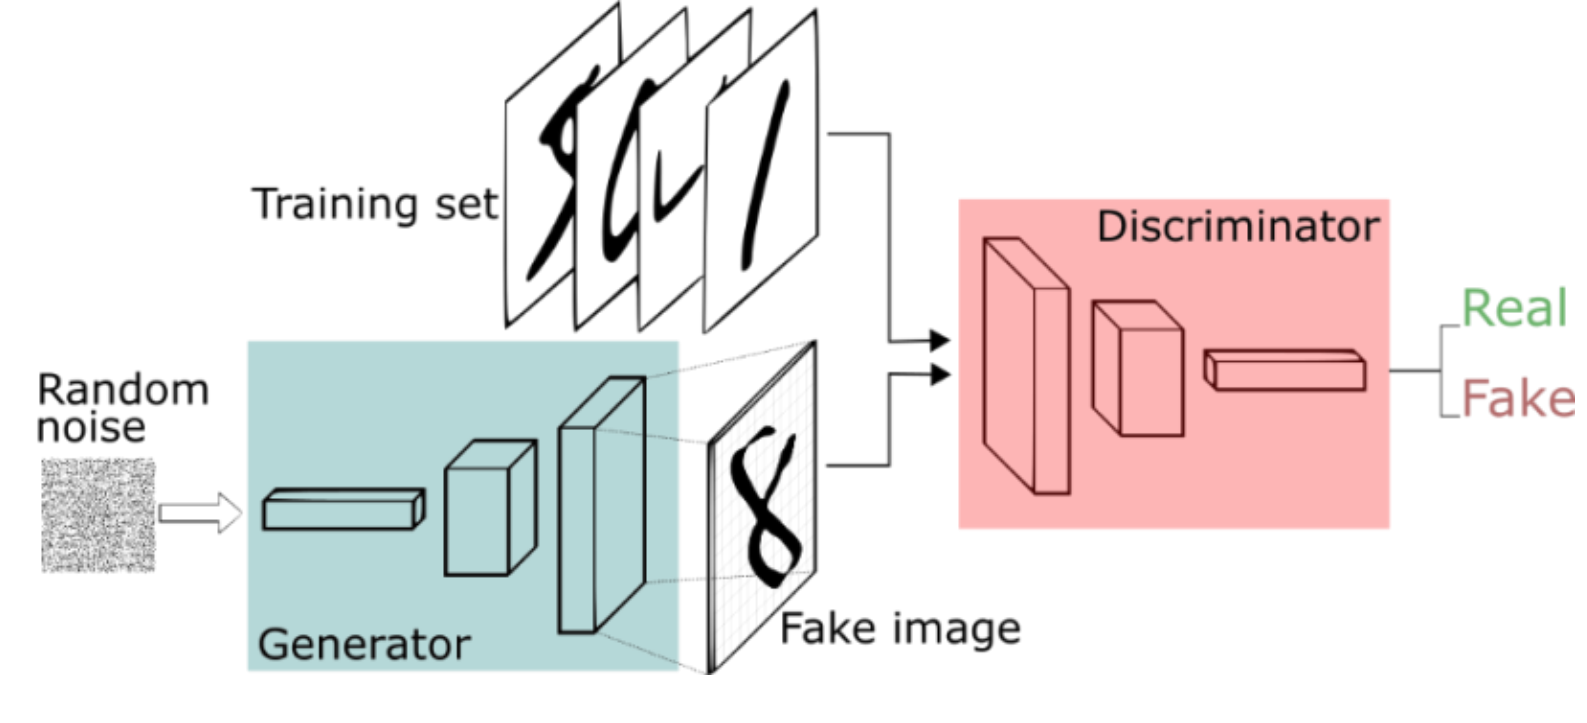

GAN (Generative Adversarial Network) terdiri dari dua jaringan neural yang bekerja secara bersamaan, yaitu Generator dan Discriminator. Kedua jaringan ini saling berkompetisi sehingga kemampuan masing-masing terus meningkat.

- Generator bertugas menghasilkan gambar baru. Input yang diterima berupa random noise, yaitu sekumpulan angka acak yang belum memiliki bentuk visual. Dari input tersebut, Generator membuat gambar palsu (fake image) semirip mungkin dengan gambar asli.

- Discriminator bertugas membedakan apakah gambar yang diterimanya merupakan gambar asli (real) atau gambar palsu (fake). Saat training, Discriminator menerima dua jenis gambar secara bergantian, yaitu gambar asli dari dataset dan gambar palsu yang dibuat oleh Generator. Tujuannya supaya Discriminator semakin baik dalam mengklasifikasikan gambar tersebut.

- Selanjutnya proses adversarial atau kompetisi kedua jaringan. Generator berusaha menghasilkan gambar yang dapat menipu Discriminator agar dianggap gambar asli. Sebaliknya, Discriminator belajar supaya tidak mudah tertipu dan semakin baik dalam mengenali gambar palsu. Seiring berjalannya training, kemampuan kedua jaringan akan meningkat. Karena Discriminator semakin pintar mendeteksi gambar palsu, Generator juga dipaksa menghasilkan gambar yang semakin baik dan menyerupai gambar asli.

- Setelah proses training stabil (konvergen), Generator mampu menghasilkan gambar yang realistis sehingga Discriminator sulit membedakan gambar asli atau hasil generasi. Pada tahap ini, Generator dapat digunakan untuk menghasilkan gambar baru (image generation).

# Soal 3b. [LO 3, LO 4, 10 poin] Buatlah arsitektur untuk image generation sesuai dengan gambar arsitektur GAN berikut ini. Lakukan evaluasi kesamaan distribusi citra dengan menggunakan Fréchet Inception Distance (FID) pada data test.

In [1]:
!pip install pytorch-fid -q

import os
import random
import numpy as np
from PIL import Image
import zipfile

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms
import torchvision.utils as vutils

from pytorch_fid import fid_score


SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


##Ekstraksi Dataset

saya menggabungkan dataset plane dan car dari folder overhead ke 1 folder terpisah yang dinamakan dataset3, hal ini dilakukan untuk mempermudah loading data dan labeling

In [2]:
zip_path = "/content/dataset3.zip"
extract_path = "/content/"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset berhasil diekstrak!")

for root, dirs, files in os.walk("/content/dataset3"):
    level = root.replace("/content/dataset3", "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/  ({len(files)} files)")


Dataset berhasil diekstrak!
dataset3/  (0 files)
  oplane/  (1000 files)
  car/  (1000 files)


##Konfigurasi Hyperparameter

- Ukuran gambar: 28 × 28 piksel (grayscale)
- Jumlah kelas: 2 (oplane dan car)
- Dimensi noise: 100
- Batch size: 64
- Learning rate: 0.0002
- Epoch: 100
- Test split: 20%

oplane label 0, car label 1

In [3]:
IMG_SIZE    = 28
N_LABELS    = 2
NOISE_DIM   = 100
BATCH_SIZE  = 64
LR          = 2e-4
N_EPOCHS    = 100
TEST_SPLIT  = 0.2

LABEL_MAP = {"oplane": 0, "car": 1}
print("Konfigurasi:")
print(f"  IMG_SIZE  : {IMG_SIZE}x{IMG_SIZE} (grayscale)")
print(f"  N_LABELS  : {N_LABELS}")
print(f"  NOISE_DIM : {NOISE_DIM}")
print(f"  BATCH_SIZE: {BATCH_SIZE}")
print(f"  N_EPOCHS  : {N_EPOCHS}")

Konfigurasi:
  IMG_SIZE  : 28x28 (grayscale)
  N_LABELS  : 2
  NOISE_DIM : 100
  BATCH_SIZE: 64
  N_EPOCHS  : 100


## Custom Dataset

Setiap gambar diubah menjadi grayscale, kemudian dilakukan tahapan preprocessing yang meliputi:

- Mengubah ukuran gambar menjadi 28 × 28 piksel.
- Mengubah gambar menjadi tensor.
- Melakukan normalisasi ke rentang [-1, 1] agar sesuai dengan fungsi aktivasi Tanh pada Generator.

Setelah seluruh data berhasil dimuat, dataset dibagi menjadi data training (80%) dan testing (20%) menggunakan random_split. Selanjutnya dibuat DataLoader agar proses pengambilan data selama training menjadi lebih efisien.

In [4]:
class PlaneCarDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.samples   = []
        self.transform = transform

        for class_name, label in LABEL_MAP.items():
            class_dir = os.path.join(root_dir, class_name)
            if not os.path.isdir(class_dir):
                print(f"Folder tidak ditemukan: {class_dir}")
                continue
            for fname in os.listdir(class_dir):
                if fname.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
                    self.samples.append((os.path.join(class_dir, fname), label))

        print(f"Total sampel: {len(self.samples)}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("L")
        if self.transform:
            img = self.transform(img)
        return img, label


transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])   # → [-1, 1]
])

full_dataset = PlaneCarDataset("/content/dataset3", transform=transform)

n_test  = int(len(full_dataset) * TEST_SPLIT)
n_train = len(full_dataset) - n_test
train_dataset, test_dataset = random_split(full_dataset, [n_train, n_test],
                                            generator=torch.Generator().manual_seed(SEED))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train: {n_train} | Test: {n_test}")


Total sampel: 2000
Train: 1600 | Test: 400


## Arsitektur Model CGAN

Generator menerima dua buah input, yaitu noise acak berdimensi 100 dan label kelas. Label terlebih dahulu diubah menjadi representasi embedding, kemudian digabungkan dengan noise sebagai masukan jaringan. Layer terakhir menggunakan aktivasi Tanh sehingga nilai output berada pada rentang [-1,1], kemudian hasilnya diubah menjadi citra berukuran 1 × 28 × 28.

Discriminator menerima gambar beserta label kelas sebagai input. Gambar terlebih dahulu diubah menjadi bentuk vektor, kemudian digabungkan dengan embedding label sebelum diproses oleh jaringan. Arsitektur Discriminator terdiri dari beberapa Fully Connected Layer dengan aktivasi LeakyReLU pada setiap hidden layer. Layer terakhir menggunakan aktivasi Sigmoid untuk menghasilkan probabilitas apakah gambar termasuk gambar asli atau gambar hasil Generator.

In [5]:
class Generator(nn.Module):
    def __init__(self, noise_dim, n_labels, img_size):
        super().__init__()
        self.label_emb = nn.Embedding(n_labels, n_labels)
        self.img_size  = img_size

        in_dim = noise_dim + n_labels

        self.net = nn.Sequential(
            nn.Linear(in_dim, 128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(1024, img_size * img_size),
            nn.Tanh()
        )

    def forward(self, noise, labels):
        label_input = self.label_emb(labels)
        x = torch.cat([noise, label_input], dim=1)
        x = self.net(x)
        x = x.view(x.size(0), 1, self.img_size, self.img_size)
        return x


class Discriminator(nn.Module):
    def __init__(self, n_labels, img_size):
        super().__init__()
        self.label_emb = nn.Embedding(n_labels, n_labels)

        in_dim = n_labels + img_size * img_size

        self.net = nn.Sequential(
            nn.Linear(in_dim, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(1024, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 1),
            nn.Sigmoid()
        )

    def forward(self, imgs, labels):
        label_input = self.label_emb(labels)
        imgs_flat   = imgs.view(imgs.size(0), -1)
        x = torch.cat([imgs_flat, label_input], dim=1)
        return self.net(x)

G = Generator(NOISE_DIM, N_LABELS, IMG_SIZE).to(device)
D = Discriminator(N_LABELS, IMG_SIZE).to(device)

print("Generator")
print(G)
print(f"\nTotal params G: {sum(p.numel() for p in G.parameters()):,}")
print("\nDiscriminator")
print(D)
print(f"\nTotal params D: {sum(p.numel() for p in D.parameters()):,}")


Generator
Generator(
  (label_emb): Embedding(2, 2)
  (net): Sequential(
    (0): Linear(in_features=102, out_features=128, bias=True)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Linear(in_features=128, out_features=256, bias=True)
    (3): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Linear(in_features=256, out_features=512, bias=True)
    (6): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Linear(in_features=512, out_features=1024, bias=True)
    (9): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2, inplace=True)
    (11): Linear(in_features=1024, out_features=784, bias=True)
    (12): Tanh()
  )
)

Total params G: 1,510,292

Discriminator
Discriminator(
  (label_emb): Embedding(2, 2)
  (net): Sequential

## Loss Function & Optimizer

loss function Binary Cross Entropy Loss (BCELoss)
Learning rate = 0.0002
Betas = (0.5, 0.999)

In [6]:
criterion = nn.BCELoss()

optimizer_G = optim.Adam(G.parameters(), lr=LR, betas=(0.5, 0.999))
optimizer_D = optim.Adam(D.parameters(), lr=LR, betas=(0.5, 0.999))

print("Loss    : BCELoss")
print("Optimizer: Adam (lr={}, betas=(0.5, 0.999))".format(LR))


Loss    : BCELoss
Optimizer: Adam (lr=0.0002, betas=(0.5, 0.999))


## Training Loop

In [7]:
os.makedirs("/content/sample_images", exist_ok=True)

G_losses, D_losses = [], []

fixed_noise  = torch.randn(16, NOISE_DIM, device=device)
fixed_labels = torch.tensor([0]*8 + [1]*8, device=device)


for epoch in range(1, N_EPOCHS + 1):
    G.train(); D.train()
    epoch_loss_G, epoch_loss_D = 0.0, 0.0

    for batch_idx, (real_imgs, labels) in enumerate(train_loader):
        real_imgs = real_imgs.to(device)
        labels    = labels.to(device)
        batch_sz  = real_imgs.size(0)

        real_targets = torch.ones(batch_sz, 1, device=device)
        fake_targets = torch.zeros(batch_sz, 1, device=device)

        # train Discriminator
        optimizer_D.zero_grad()

        # Loss pada real images
        out_real  = D(real_imgs, labels)
        loss_real = criterion(out_real, real_targets)

        # Generate fake images
        noise     = torch.randn(batch_sz, NOISE_DIM, device=device)
        fake_imgs = G(noise, labels)

        # Loss pada fake images
        out_fake  = D(fake_imgs.detach(), labels)
        loss_fake = criterion(out_fake, fake_targets)

        loss_D = (loss_real + loss_fake) / 2
        loss_D.backward()
        optimizer_D.step()


        # train Generator
        optimizer_G.zero_grad()

        out_fake_for_G = D(fake_imgs, labels)
        loss_G = criterion(out_fake_for_G, real_targets)

        loss_G.backward()
        optimizer_G.step()

        epoch_loss_G += loss_G.item()
        epoch_loss_D += loss_D.item()

    avg_G = epoch_loss_G / len(train_loader)
    avg_D = epoch_loss_D / len(train_loader)
    G_losses.append(avg_G)
    D_losses.append(avg_D)

    if epoch % 10 == 0 or epoch == 1:
        print(f"[Epoch {epoch:>3}/{N_EPOCHS}]  Loss_D: {avg_D:.4f}  |  Loss_G: {avg_G:.4f}")

        G.eval()
        with torch.no_grad():
            samples = G(fixed_noise, fixed_labels)
        vutils.save_image(samples, f"/content/sample_images/epoch_{epoch:03d}.png",
                          nrow=8, normalize=True)


[Epoch   1/100]  Loss_D: 0.6373  |  Loss_G: 0.8953
[Epoch  10/100]  Loss_D: 0.3499  |  Loss_G: 3.6738
[Epoch  20/100]  Loss_D: 0.3332  |  Loss_G: 3.1362
[Epoch  30/100]  Loss_D: 0.3213  |  Loss_G: 2.7719
[Epoch  40/100]  Loss_D: 0.3367  |  Loss_G: 2.6506
[Epoch  50/100]  Loss_D: 0.3213  |  Loss_G: 2.6579
[Epoch  60/100]  Loss_D: 0.3445  |  Loss_G: 2.6126
[Epoch  70/100]  Loss_D: 0.3213  |  Loss_G: 2.8592
[Epoch  80/100]  Loss_D: 0.3149  |  Loss_G: 2.9785
[Epoch  90/100]  Loss_D: 0.2613  |  Loss_G: 3.1588
[Epoch 100/100]  Loss_D: 0.2992  |  Loss_G: 2.8802


##Visualisasi Training Loss

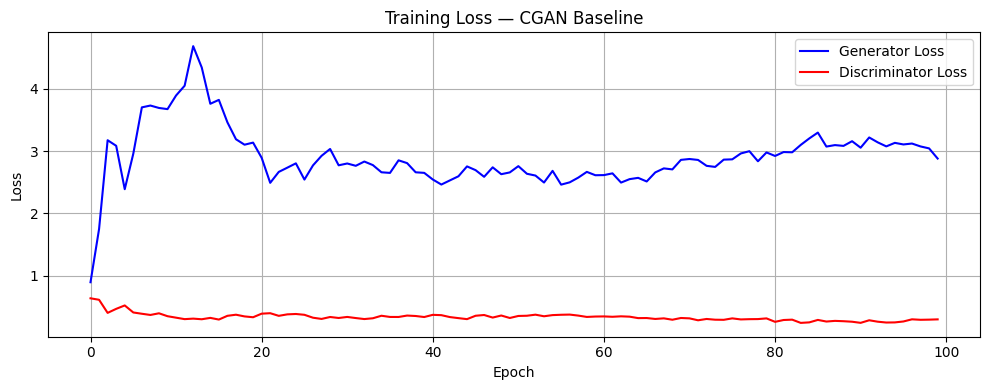

 disimpan ke /content/training_loss.png


In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(G_losses, label="Generator Loss",     color="blue")
plt.plot(D_losses, label="Discriminator Loss", color="red")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss — CGAN Baseline")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("/content/training_loss.png", dpi=150)
plt.show()
print(" disimpan ke /content/training_loss.png")


tidak terlihat adanya fluktuasi ekstrem pada kedua loss, sehingga proses training dapat dikatakan cukup stabil hingga akhir epoch.

##Visualisasi Sample Gambar Generator

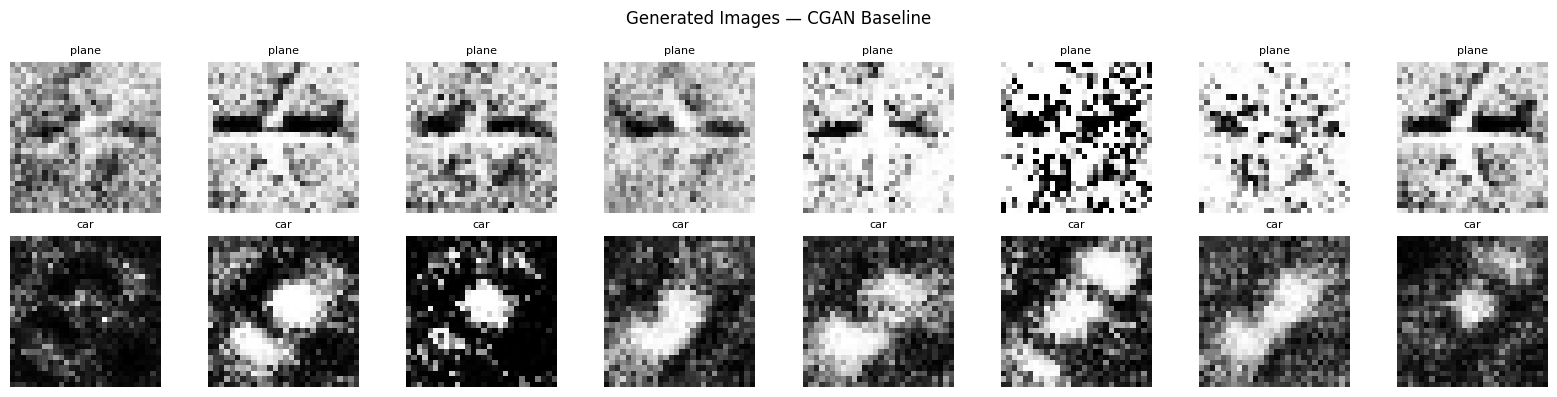

disimpan ke /content/generated_samples.png


In [9]:
G.eval()
with torch.no_grad():
    sample_noise  = torch.randn(16, NOISE_DIM, device=device)
    sample_labels = torch.tensor([0]*8 + [1]*8, device=device)
    fake_samples  = G(sample_noise, sample_labels)

fake_samples = (fake_samples * 0.5 + 0.5).cpu()

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
label_names = {0: "plane", 1: "car"}

for i, ax in enumerate(axes.flatten()):
    ax.imshow(fake_samples[i].squeeze(), cmap="gray")
    ax.set_title(label_names[sample_labels[i].item()], fontsize=8)
    ax.axis("off")

plt.suptitle("Generated Images — CGAN Baseline", fontsize=12)
plt.tight_layout()
plt.savefig("/content/generated_samples.png", dpi=150)
plt.show()
print("disimpan ke /content/generated_samples.png")


## Evaluasi FID

In [10]:
FID_REAL_DIR = "/content/fid_real"
FID_FAKE_DIR = "/content/fid_fake"
os.makedirs(FID_REAL_DIR, exist_ok=True)
os.makedirs(FID_FAKE_DIR, exist_ok=True)

print("simpen gambar real dari test set")
inv_transform = transforms.Compose([
    transforms.Normalize(mean=[-1.0], std=[2.0]),
    transforms.ToPILImage()
])

idx = 0
for real_imgs, _ in test_loader:
    for img_tensor in real_imgs:
        pil_img = inv_transform(img_tensor)
        pil_img.convert("RGB").save(os.path.join(FID_REAL_DIR, f"real_{idx:05d}.png"))
        idx += 1

n_fid = idx
print(f" gambar real tersimpan: {n_fid}")

print("\ngenerate gambar fake untuk FID")
G.eval()
idx = 0
with torch.no_grad():
    while idx < n_fid:
        sz    = min(BATCH_SIZE, n_fid - idx)
        noise = torch.randn(sz, NOISE_DIM, device=device)

        lbls  = torch.tensor([i % N_LABELS for i in range(idx, idx + sz)], device=device)
        fake  = G(noise, lbls)
        fake  = (fake * 0.5 + 0.5).clamp(0, 1).cpu()

        for img_tensor in fake:
            pil_img = transforms.ToPILImage()(img_tensor)
            pil_img.convert("RGB").save(os.path.join(FID_FAKE_DIR, f"fake_{idx:05d}.png"))
            idx += 1

print(f"gambar fake tersimpan: {idx}")


simpen gambar real dari test set
 gambar real tersimpan: 400

generate gambar fake untuk FID
gambar fake tersimpan: 400


In [11]:
print("Menghitung FID score")

fid_value = fid_score.calculate_fid_given_paths(
    [FID_REAL_DIR, FID_FAKE_DIR],
    batch_size=64,
    device=device,
    dims=2048
)


print(f"  FID Score (Baseline CGAN) : {fid_value:.4f}")


Menghitung FID score
Downloading: "https://github.com/mseitzer/pytorch-fid/releases/download/fid_weights/pt_inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/pt_inception-2015-12-05-6726825d.pth


100%|██████████| 91.2M/91.2M [00:00<00:00, 302MB/s]
100%|██████████| 7/7 [00:01<00:00,  4.33it/s]


  FID Score (Baseline CGAN) : 239.8994


Hasil evaluasi menunjukkan bahwa model Baseline CGAN memperoleh FID Score sebesar 239.8994.

Nilai ini menunjukkan bahwa Generator telah mampu menghasilkan gambar sesuai kelas yang diminta, namun distribusi gambar yang dihasilkan masih cukup berbeda dibandingkan distribusi gambar asli.

## Simpan Model

In [12]:
torch.save(G.state_dict(), "/content/generator_baseline.pth")
torch.save(D.state_dict(), "/content/discriminator_baseline.pth")
print("Model disimpan:")
print("  /content/generator_baseline.pth")
print("  /content/discriminator_baseline.pth")


Model disimpan:
  /content/generator_baseline.pth
  /content/discriminator_baseline.pth


# 3c. [LO 1, LO 2, LO 3, LO 4, 10 poin] Setelah mengetahui hasil dari nomor (3b), modifikasi arsitektur GAN di atas agar mendapatkan metrik Fréchet Inception Distance (FID) yang lebih baik. Berikan alasan mengapa modifikasi arsitektur dan metode tuning hyperparameter kalian lebih baik.

dilakukan beberapa penyesuaian pada arsitektur dan hyperparameter, yaitu:

- Mengubah ukuran gambar dari 28×28 menjadi 32×32.
- Mengganti arsitektur Fully Connected menjadi - Convolutional CGAN (ConvTranspose pada Generator dan Convolution pada Discriminator).
- Menurunkan learning rate Generator dan Discriminator agar proses training lebih stabil.
- Menambah jumlah epoch dari 100 menjadi 200.
- Menambah n_critic = 2, sehingga Discriminator diperbarui dua kali untuk setiap pembaruan Generator.
- Menyederhanakan arsitektur Generator dan Discriminator

In [13]:
IMG_SIZE     = 32
N_LABELS     = 2
NOISE_DIM    = 100
EMBED_DIM    = N_LABELS
BATCH_SIZE   = 64
LR_G         = 1e-4
LR_D         = 5e-5
N_EPOCHS     = 200
N_CRITIC     = 2
LABEL_SMOOTH = 0.9
TEST_SPLIT   = 0.2

LABEL_MAP = {"oplane": 0, "car": 1}

print("Konfigurasi 3c:")
for k, v in {
    "IMG_SIZE": f"{IMG_SIZE}×{IMG_SIZE}",
    "LR_G / LR_D": f"{LR_G} / {LR_D}",
    "N_EPOCHS": N_EPOCHS,
    "N_CRITIC": N_CRITIC,
    "Label Smoothing": LABEL_SMOOTH,
}.items():
    print(f"  {k:20s}: {v}")


Konfigurasi 3c (Revised):
  IMG_SIZE            : 32×32
  LR_G / LR_D         : 0.0001 / 5e-05
  N_EPOCHS            : 200
  N_CRITIC            : 2
  Label Smoothing     : 0.9


## custom dataset

In [14]:
class PlaneCarDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.samples   = []
        self.transform = transform
        for class_name, label in LABEL_MAP.items():
            class_dir = os.path.join(root_dir, class_name)
            if not os.path.isdir(class_dir):
                print(f"Tidak ditemukan: {class_dir}")
                continue
            for fname in os.listdir(class_dir):
                if fname.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
                    self.samples.append((os.path.join(class_dir, fname), label))
        print(f"Total sampel: {len(self.samples)}")

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("L")
        if self.transform: img = self.transform(img)
        return img, label


transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

full_dataset = PlaneCarDataset("/content/dataset3", transform=transform)
n_test  = int(len(full_dataset) * TEST_SPLIT)
n_train = len(full_dataset) - n_test
train_dataset, test_dataset = random_split(
    full_dataset, [n_train, n_test],
    generator=torch.Generator().manual_seed(SEED)
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train: {n_train} | Test: {n_test}")


Total sampel: 2000
Train: 1600 | Test: 400


## Arsitektur Model


Generator menggunakan ConvTranspose2D untuk membangun gambar secara bertahap dari ukuran kecil hingga menjadi citra 32 × 32 piksel. Dibandingkan baseline yang menggunakan beberapa Fully Connected Layer, ini lebih sesuai untuk image generation karena mampu mempertahankan informasi spasial pada gambar. Label kelas digabungkan dengan noise menggunakan embedding, sehingga Generator dapat menghasilkan gambar sesuai dengan kelas yang diinginkan.

Discriminator menggunakan beberapa Convolution Layer untuk mengekstraksi fitur gambar, kemudian memanfaatkan Spectral Normalization agar proses training lebih stabil dan mengurangi risiko Discriminator menjadi terlalu dominan. Label kelas juga diubah menjadi label map dan digabungkan dengan gambar sebagai input, sehingga Discriminator tidak hanya menilai keaslian gambar tetapi juga kesesuaiannya dengan label.

In [15]:
from torch.nn.utils import spectral_norm
class Generator(nn.Module):
    def __init__(self, noise_dim, embed_dim, n_labels):
        super().__init__()
        self.label_emb = nn.Embedding(n_labels, embed_dim)

        self.project = nn.Sequential(
            nn.Linear(noise_dim + embed_dim, 256 * 4 * 4, bias=False),
            nn.ReLU(inplace=True)
        )

        self.conv_blocks = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(64, 1, kernel_size=4, stride=2, padding=1, bias=False),
            nn.Tanh()
        )

    def forward(self, noise, labels):
        emb = self.label_emb(labels)
        x   = torch.cat([noise, emb], dim=1)
        x   = self.project(x).view(-1, 256, 4, 4)
        return self.conv_blocks(x)


class Discriminator(nn.Module):
    def __init__(self, n_labels, img_size):
        super().__init__()
        self.img_size   = img_size
        self.label_proj = nn.Embedding(n_labels, img_size * img_size)

        self.conv_blocks = nn.Sequential(
            spectral_norm(nn.Conv2d(2, 64, kernel_size=4, stride=2, padding=1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),

            spectral_norm(nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1, bias=False)),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            spectral_norm(nn.Conv2d(128, 1, kernel_size=4, stride=1, padding=0, bias=False)),
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.out  = nn.Sigmoid()

    def forward(self, imgs, labels):
        lmap = self.label_proj(labels).view(-1, 1, self.img_size, self.img_size)
        x    = torch.cat([imgs, lmap], dim=1)
        x    = self.conv_blocks(x)
        x    = self.pool(x).view(x.size(0), 1)
        return self.out(x)



def weights_init(m):
    cname = m.__class__.__name__
    if "Conv" in cname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif "BatchNorm" in cname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


G = Generator(NOISE_DIM, EMBED_DIM, N_LABELS).to(device)
D = Discriminator(N_LABELS, IMG_SIZE).to(device)
G.apply(weights_init)
D.apply(weights_init)


print(G)
print(f"\nTotal params G: {sum(p.numel() for p in G.parameters()):,}")
print(D)
print(f"\nTotal params D: {sum(p.numel() for p in D.parameters()):,}")


Generator(
  (label_emb): Embedding(2, 2)
  (project): Sequential(
    (0): Linear(in_features=102, out_features=4096, bias=False)
    (1): ReLU(inplace=True)
  )
  (conv_blocks): Sequential(
    (0): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(64, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): Tanh()
  )
)

Total params G: 1,074,564
Discriminator(
  (label_proj): Embedding(2, 1024)
  (conv_blocks): Sequential(
    (0): Conv2d(2, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(

##Loss Function & Optimizer

loss tetap, learning rate dibuat berbeda:
- Generator: 0.0001
- Discriminator: 0.00005

In [16]:
criterion = nn.BCELoss()

optimizer_G = optim.Adam(G.parameters(), lr=LR_G, betas=(0.5, 0.999))
optimizer_D = optim.Adam(D.parameters(), lr=LR_D, betas=(0.5, 0.999))

scheduler_G = optim.lr_scheduler.MultiStepLR(optimizer_G, milestones=[100, 150], gamma=0.5)
scheduler_D = optim.lr_scheduler.MultiStepLR(optimizer_D, milestones=[100, 150], gamma=0.5)

## Training Loop

In [17]:
os.makedirs("/content/samples_3c_v2", exist_ok=True)

G_losses, D_losses = [], []
fixed_noise  = torch.randn(16, NOISE_DIM, device=device)
fixed_labels = torch.tensor([0]*8 + [1]*8, device=device)

for epoch in range(1, N_EPOCHS + 1):
    G.train(); D.train()
    epoch_loss_G = 0.0
    epoch_loss_D = 0.0

    for real_imgs, labels in train_loader:
        real_imgs = real_imgs.to(device)
        labels    = labels.to(device)
        batch_sz  = real_imgs.size(0)

        real_targets = torch.full((batch_sz, 1), LABEL_SMOOTH, device=device)
        fake_targets = torch.zeros(batch_sz, 1, device=device)

        for _ in range(N_CRITIC):
            optimizer_D.zero_grad()

            out_real  = D(real_imgs, labels)
            loss_real = criterion(out_real, real_targets)

            noise     = torch.randn(batch_sz, NOISE_DIM, device=device)
            fake_imgs = G(noise, labels).detach()

            out_fake  = D(fake_imgs, labels)
            loss_fake = criterion(out_fake, fake_targets)

            loss_D = (loss_real + loss_fake) / 2
            loss_D.backward()
            optimizer_D.step()

        optimizer_G.zero_grad()

        noise     = torch.randn(batch_sz, NOISE_DIM, device=device)
        fake_imgs = G(noise, labels)
        out_fake  = D(fake_imgs, labels)
        loss_G    = criterion(out_fake, torch.ones(batch_sz, 1, device=device))

        loss_G.backward()
        optimizer_G.step()

        epoch_loss_G += loss_G.item()
        epoch_loss_D += loss_D.item()

    scheduler_G.step()
    scheduler_D.step()

    avg_G = epoch_loss_G / len(train_loader)
    avg_D = epoch_loss_D / len(train_loader)
    G_losses.append(avg_G)
    D_losses.append(avg_D)

    if epoch % 20 == 0 or epoch == 1:
        print(f"[Epoch {epoch:>3}/{N_EPOCHS}]  Loss_D: {avg_D:.4f}  |  Loss_G: {avg_G:.4f}")
        G.eval()
        with torch.no_grad():
            samples = G(fixed_noise, fixed_labels)
        vutils.save_image(samples, f"/content/samples_3c_v2/epoch_{epoch:03d}.png",
                          nrow=8, normalize=True)
        G.train()


[Epoch   1/200]  Loss_D: 0.6196  |  Loss_G: 0.8997
[Epoch  20/200]  Loss_D: 0.5944  |  Loss_G: 0.9860
[Epoch  40/200]  Loss_D: 0.5870  |  Loss_G: 0.9750
[Epoch  60/200]  Loss_D: 0.6169  |  Loss_G: 0.9230
[Epoch  80/200]  Loss_D: 0.6249  |  Loss_G: 0.9106
[Epoch 100/200]  Loss_D: 0.6265  |  Loss_G: 0.9065
[Epoch 120/200]  Loss_D: 0.6247  |  Loss_G: 0.8909
[Epoch 140/200]  Loss_D: 0.6224  |  Loss_G: 0.8943
[Epoch 160/200]  Loss_D: 0.6223  |  Loss_G: 0.8913
[Epoch 180/200]  Loss_D: 0.6218  |  Loss_G: 0.8891
[Epoch 200/200]  Loss_D: 0.6211  |  Loss_G: 0.8933


##Visualisasi Training Loss

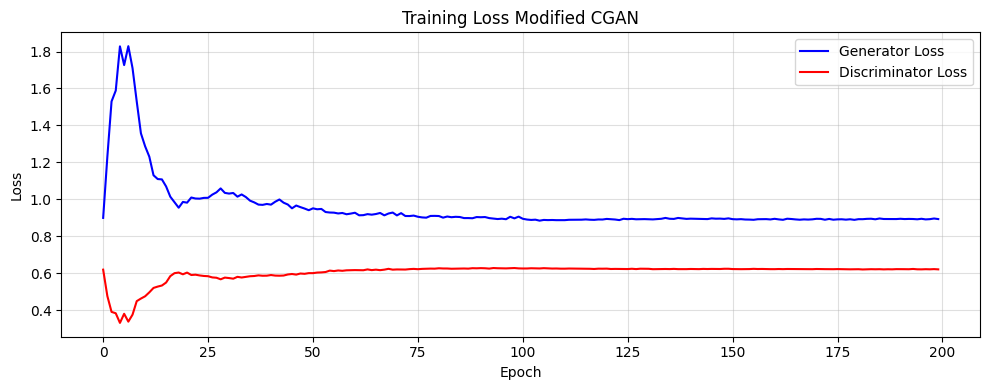

In [18]:
plt.figure(figsize=(10, 4))
plt.plot(G_losses, label="Generator Loss",     color="blue",  linewidth=1.5)
plt.plot(D_losses, label="Discriminator Loss", color="red",   linewidth=1.5)
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("Training Loss Modified CGAN")
plt.legend(); plt.grid(True, alpha=0.4); plt.tight_layout()
plt.savefig("/content/loss_3c_v2.png", dpi=150)
plt.show()


kedua nilai loss terlihat lebih stabil dengan fluktuasi yang jauh lebih kecil.

##Visualisasi Sample Gambar

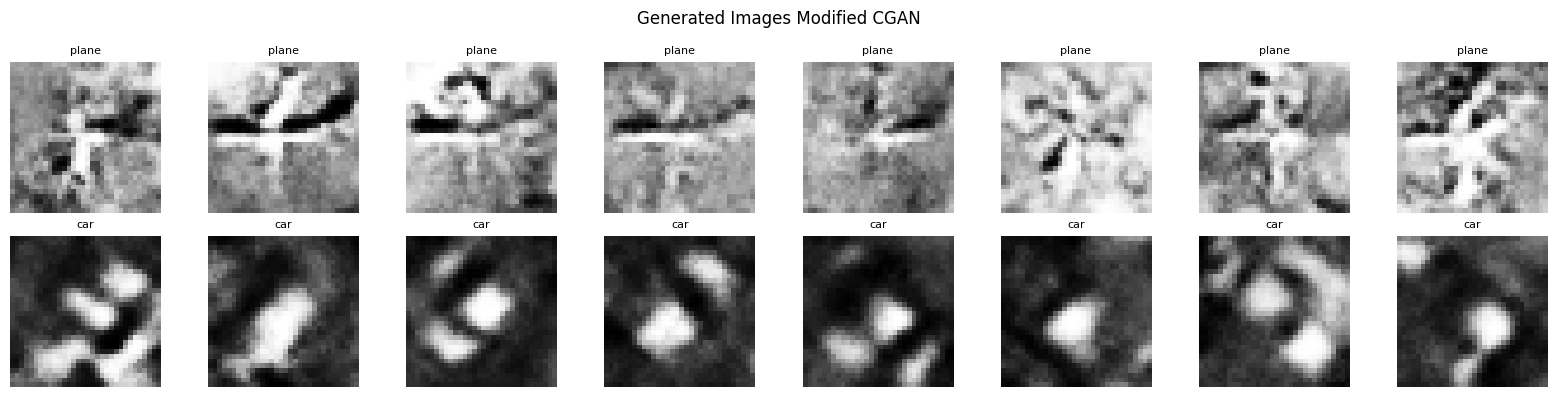

In [19]:
G.eval()
with torch.no_grad():
    sample_noise  = torch.randn(16, NOISE_DIM, device=device)
    sample_labels = torch.tensor([0]*8 + [1]*8, device=device)
    fake_samples  = G(sample_noise, sample_labels)

fake_samples = (fake_samples * 0.5 + 0.5).clamp(0, 1).cpu()
label_names  = {0: "plane", 1: "car"}

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(fake_samples[i].squeeze(), cmap="gray")
    ax.set_title(label_names[sample_labels[i].item()], fontsize=8)
    ax.axis("off")

plt.suptitle("Generated Images Modified CGAN", fontsize=12)
plt.tight_layout()
plt.savefig("/content/samples_final_3c_v2.png", dpi=150)
plt.show()


### Evaluasi FID pada Data Test

In [20]:
FID_REAL_DIR = "/content/fid_real_3c_v2"
FID_FAKE_DIR = "/content/fid_fake_3c_v2"
os.makedirs(FID_REAL_DIR, exist_ok=True)
os.makedirs(FID_FAKE_DIR, exist_ok=True)

to_inception = transforms.Compose([
    transforms.Resize((299, 299), interpolation=transforms.InterpolationMode.BICUBIC),
])

# simpan gambar rela
denorm = transforms.Normalize(mean=[-1.0], std=[2.0])

idx = 0
for real_imgs, _ in test_loader:
    for img_tensor in real_imgs:
        img_01    = denorm(img_tensor).clamp(0, 1)
        img_pil   = transforms.ToPILImage()(img_01)
        img_299   = to_inception(img_pil).convert("RGB")
        img_299.save(os.path.join(FID_REAL_DIR, f"real_{idx:05d}.png"))
        idx += 1

n_fid = idx
print(f"Total gambar real: {n_fid}")

print("\ngenerate gambar fake")
n_fake_target = max(n_fid * 2, 1000)

G.eval()
idx = 0
with torch.no_grad():
    while idx < n_fake_target:
        sz    = min(BATCH_SIZE, n_fake_target - idx)
        noise = torch.randn(sz, NOISE_DIM, device=device)
        lbls  = torch.tensor([i % N_LABELS for i in range(idx, idx + sz)], device=device)
        fake  = G(noise, lbls)
        fake  = (fake * 0.5 + 0.5).clamp(0, 1).cpu()

        for img_tensor in fake:
            img_pil = transforms.ToPILImage()(img_tensor)
            img_299 = to_inception(img_pil).convert("RGB")
            img_299.save(os.path.join(FID_FAKE_DIR, f"fake_{idx:05d}.png"))
            idx += 1

print(f"Total gambar fake: {idx}")


Total gambar real: 400

generate gambar fake
Total gambar fake: 1000


In [21]:
fid_value = fid_score.calculate_fid_given_paths(
    [FID_REAL_DIR, FID_FAKE_DIR],
    batch_size=64,
    device=device,
    dims=2048
)

fid_baseline = 239.8994


print(f"  FID Baseline (3b)        : {fid_baseline:.4f}")
print(f"  FID Modified  (3c)   : {fid_value:.4f}")
improvement = fid_baseline - fid_value
pct = (improvement / fid_baseline) * 100
print(f"  Selisih                  : {improvement:+.4f}  ({pct:+.1f}%)")
if fid_value < fid_baseline:
    print(f"FID turun {improvement:.2f} poin dari baseline.")
else:
    print(f"FID belum lebih baik.")


100%|██████████| 16/16 [00:05<00:00,  3.07it/s]


  FID Baseline (3b)        : 239.8994
  FID Modified  (3c)   : 255.2191
  Selisih                  : -15.3197  (-6.4%)
FID belum lebih baik.


- FID Baseline (3b) : 239.8994
- FID Modified (3c) : 255.2191

Nilai FID pada model modifikasi lebih tinggi dibandingkan baseline, sehingga kualitas gambar yang dihasilkan berdasarkan metrik FID belum mengalami peningkatan.

## analisis
Meskipun arsitektur yang digunakan lebih modern dan proses training terlihat lebih stabil, hasil evaluasi menunjukkan bahwa nilai FID meningkat. Distribusi gambar yang dihasilkan Generator justru sedikit lebih jauh dari distribusi gambar asli.

Beberapa kemungkinan penyebabnya adalah:

- Ukuran dataset relatif kecil, yaitu hanya 2000 gambar, sehingga Generator belum memiliki cukup variasi data untuk memanfaatkan arsitektur Convolutional secara maksimal.
- Learning rate yang lebih kecil membuat proses training lebih stabil, tetapi juga menyebabkan Generator belajar lebih lambat sehingga kualitas gambar belum meningkat secara signifikan meskipun jumlah epoch sudah ditambah.
- Penggunaan Spectral Normalization, Label Smoothing, dan n_critic = 2 memang membantu menjaga keseimbangan antara Generator dan Discriminator, tetapi pada dataset yang kecil kombinasi tersebut dapat membuat Generator lebih sulit mengejar kemampuan Discriminator.
- Perubahan resolusi gambar dari 28 × 28 menjadi 32 × 32 juga membuat Generator harus mempelajari detail gambar yang lebih banyak, sehingga tingkat kesulitan proses generasi meningkat.

Modifikasi yang dilakukan berhasil membuat proses training menjadi lebih stabil, tetapi belum mampu meningkatkan kualitas gambar berdasarkan metrik FID. Ini menunjukkan bahwa stabilitas training tidak berbanding lurus dengan peningkatan performa model, ketika ukuran dataset masih terbatas.

## simpan model

In [22]:
torch.save(G.state_dict(), "/content/generator_3c_revised.pth")
torch.save(D.state_dict(), "/content/discriminator_3c_revised.pth")
print("Model disimpan:")
print("  /content/generator_3c_revised.pth")
print("  /content/discriminator_3c_revised.pth")


Model disimpan:
  /content/generator_3c_revised.pth
  /content/discriminator_3c_revised.pth
